# IMPORT LIBRARY

In [144]:
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd

# NONAKTIFKAN PERINGATAN CHAINING
pd.options.mode.chained_assignment 

import numpy as np

# MENGATUR SEED UNTUK PRODUKTIVITAS
seed = 0
np.random.seed(seed)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

import datetime as dt
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tabiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tabiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# LOAD DATASET

In [145]:
app_reviews = pd.read_csv('app_reviews.csv')
app_reviews_df = pd.DataFrame(app_reviews)

app_reviews_df.shape
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,6eea01f6-2e19-41fa-bd2c-e9ed706dd4b3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,NaN,2026-06-14 19:00:29,"Hai Kak, makasih banyak buat rating dan suppor...",2026-06-14 21:42:02,NaN
1,f535831f-f338-4b97-b404-49195e98ecca,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,cocok sih buat aku suka banget apalagi dapet koin,5,0,1.64.6,2026-06-14 18:57:12,"Hello, Kak Alvian. Makasih banyak buat feedbac...",2026-06-14 21:45:33,1.64.6
2,99e98d79-cf68-4c55-8588-ebc71735e17b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,2,0,1.64.6,2026-06-14 18:53:27,"Hai Kak Aganda, makasih banyak buat rating dan...",2026-06-14 21:40:20,1.64.6
3,53b512a3-e52a-42ac-b74c-921719e7f9d6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi cacat korup, beli kouta masa koutanya...",1,0,1.64.6,2026-06-14 18:51:29,"Hai Kak, maaf udah bikin ga nyaman ya :( Kalau...",2026-06-14 21:42:19,1.64.6
4,f9c428ce-d88b-4e79-aabf-c4e0abac8b84,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,5,0,1.64.6,2026-06-14 18:45:02,"Hai Kak Priskilla, makasih banyak buat rating ...",2026-06-14 21:41:08,1.64.6


In [146]:
app_reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              3000 non-null   str  
 1   userName              3000 non-null   str  
 2   userImage             3000 non-null   str  
 3   content               3000 non-null   str  
 4   score                 3000 non-null   int64
 5   thumbsUpCount         3000 non-null   int64
 6   reviewCreatedVersion  2572 non-null   str  
 7   at                    3000 non-null   str  
 8   replyContent          2992 non-null   str  
 9   repliedAt             2992 non-null   str  
 10  appVersion            2572 non-null   str  
dtypes: int64(2), str(9)
memory usage: 1.8 MB


# DROP MISSING VALUES

In [147]:
clean_df = app_reviews_df.dropna()

# DROP DUPLICATES

In [148]:
clean_df = clean_df.drop_duplicates()

In [149]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 2565 entries, 1 to 2998
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              2565 non-null   str  
 1   userName              2565 non-null   str  
 2   userImage             2565 non-null   str  
 3   content               2565 non-null   str  
 4   score                 2565 non-null   int64
 5   thumbsUpCount         2565 non-null   int64
 6   reviewCreatedVersion  2565 non-null   str  
 7   at                    2565 non-null   str  
 8   replyContent          2565 non-null   str  
 9   repliedAt             2565 non-null   str  
 10  appVersion            2565 non-null   str  
dtypes: int64(2), str(9)
memory usage: 1.5 MB


# TEXT PREPROCESSING

In [150]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # MENGHAPUS MENTION
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # MENGHAPUS HASHTAG
    text = re.sub(r'RT[\s]', '', text) # MENGHAPUS RT
    text = re.sub(r'@http\S+', '', text) # MENGHAPUS LINK
    text = re.sub(r'[0-9]+', '', text) # MENGHAPUS ANGKA
    text = re.sub(r'[^\w\s]', '', text) # MENGHAPUS KARAKTER SELAIN HURUF DAN ANGKA

    text = text.replace('\n', ' ') # GANTI BARIS BARU DENGAN SPASI
    text = text.translate(str.maketrans('', '', string.punctuation)) # HAPUS SEMUA TANDA BACA
    text = text.strip(' ') # HAPUS SPASI KANAN KIRI
    return text

def caseFoldingText(text):
    text = text.lower()
    return text

def tokenizingText(text):
    text = word_tokenize(text)
    return text

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    words = text.split()

    stemmed_words = [stemmer.stem(word) for word in words]

    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

In [151]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata negatif dari GitHub
slangwords = dict()

# Mengirim permintaan HTTP untuk mendapatkan file txt dari GitHub
response = requests.get('https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/refs/heads/master/combined_slang_words.txt')

# Jika permintaan berhasil
if response.status_code == 200:
    slangwords = response.json()
    print(f"Berhasil memuat {len(slangwords)} slang words.")
else:
    print("Failed to fetch slang words data")

def fixSlangWords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
    
    fixed_text = ' '.join(fixed_words)
    return fixed_text

Berhasil memuat 1018 slang words.


In [152]:
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(caseFoldingText)
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fixSlangWords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
1,f535831f-f338-4b97-b404-49195e98ecca,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,cocok sih buat aku suka banget apalagi dapet koin,5,0,1.64.6,2026-06-14 18:57:12,"Hello, Kak Alvian. Makasih banyak buat feedbac...",2026-06-14 21:45:33,1.64.6,cocok sih buat aku suka banget apalagi dapet koin,cocok sih buat aku suka banget apalagi dapet koin,cocok sih buat aku suka banget apalagi dapat koin,"[cocok, sih, buat, aku, suka, banget, apalagi,...","[cocok, suka, banget, koin]",cocok suka banget koin
2,99e98d79-cf68-4c55-8588-ebc71735e17b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,2,0,1.64.6,2026-06-14 18:53:27,"Hai Kak Aganda, makasih banyak buat rating dan...",2026-06-14 21:40:20,1.64.6,baik,baik,baik,[baik],[],
3,53b512a3-e52a-42ac-b74c-921719e7f9d6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi cacat korup, beli kouta masa koutanya...",1,0,1.64.6,2026-06-14 18:51:29,"Hai Kak, maaf udah bikin ga nyaman ya :( Kalau...",2026-06-14 21:42:19,1.64.6,Aplikasi cacat korup beli kouta masa koutanya ...,aplikasi cacat korup beli kouta masa koutanya ...,aplikasi cacat korupsi beli kouta masa koutany...,"[aplikasi, cacat, korupsi, beli, kouta, masa, ...","[aplikasi, cacat, korupsi, beli, kouta, koutan...",aplikasi cacat korupsi beli kouta koutanya g m...
4,f9c428ce-d88b-4e79-aabf-c4e0abac8b84,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,5,0,1.64.6,2026-06-14 18:45:02,"Hai Kak Priskilla, makasih banyak buat rating ...",2026-06-14 21:41:08,1.64.6,baik,baik,baik,[baik],[],
5,e97144e9-40f4-4344-8c10-6dd2db0b805b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"ngelag, sinyal ilang terus, bikin kesel main h...",1,0,1.64.6,2026-06-14 18:43:09,"Hi, Kak. Maaf banget udah bikin ga nyaman. Unt...",2026-06-14 21:44:05,1.64.6,ngelag sinyal ilang terus bikin kesel main hp ...,ngelag sinyal ilang terus bikin kesel main hp ...,ngelag sinyal hilang terus bikin kesel main hp...,"[ngelag, sinyal, hilang, terus, bikin, kesel, ...","[ngelag, sinyal, hilang, bikin, kesel, main, h...",ngelag sinyal hilang bikin kesel main hp tenang


# LABELING

In [153]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

# Jika permintaan berhasil
if response.status_code == 200:
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
    reader = csv.reader(StringIO(response.text), delimiter=',')

    # Mengulangi setiap baris dalam file CSV
    for row in reader:
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexiocn data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

# Jika permintaan berhasil
if response.status_code == 200:
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
    reader = csv.reader(StringIO(response.text), delimiter=',')

    # Mengulangi setiap baris dalam file CSV
    for row in reader:
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexiocn data")


# POLARITY

In [154]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0

    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
    
    for word in text:
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity = ''

    if (score >= 0):
        polarity = 'positive'
    
    elif (score < 0):
        polarity = 'negative'
    
    return score, polarity

In [155]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    1474
negative    1091
Name: count, dtype: int64


# EDA

## POLARITY

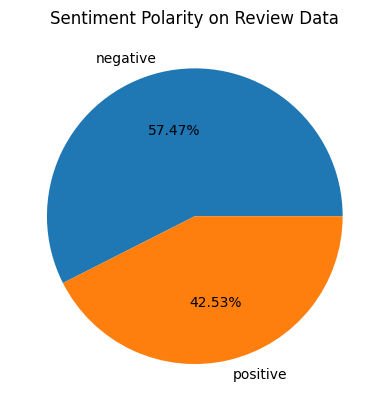

In [156]:
plt.Figure(figsize=(8, 8))
plt.pie(x=clean_df['polarity'].value_counts(), labels=['negative', 'positive'], autopct='%.2f%%')
plt.title("Sentiment Polarity on Review Data")
plt.show()

## WORDCLOUD

<function matplotlib.pyplot.show(close=None, block=None)>

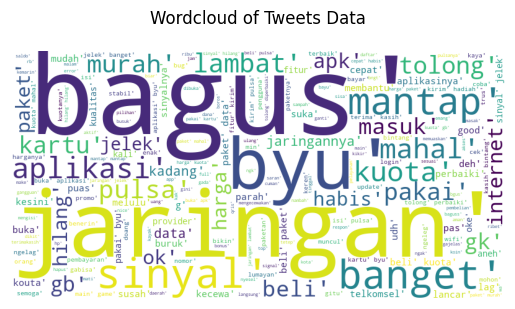

In [157]:
text = " ".join(clean_df['text_stopword'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(text)

plt.Figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Wordcloud of Tweets Data', pad=20)
plt.show

## WORDCLOUD NEGATIVE

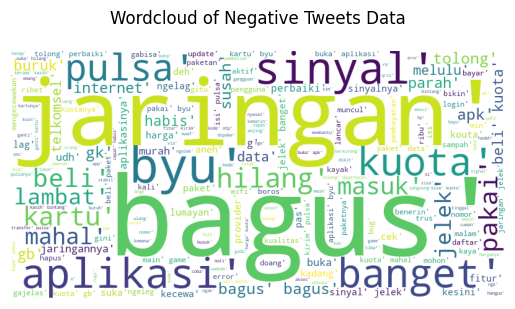

In [158]:
text_negative = " ".join(clean_df[clean_df['polarity'] == 'negative']['text_stopword'].astype(str))

wordcloud_negative = WordCloud(
    height=400,
    width=800,
    background_color='white',
    colormap='viridis'
).generate(text_negative)

plt.Figure(figsize=(10, 5))
plt.imshow(wordcloud_negative)
plt.title("Wordcloud of Negative Tweets Data", pad=20)
plt.axis('off')
plt.show()

## WORDCLOUD POSITIVE

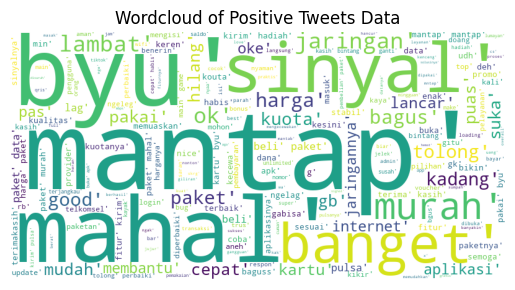

In [159]:
text_positive = " ".join(clean_df[clean_df['polarity'] == 'positive']['text_stopword'].astype(str))

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(text_positive)

plt.Figure(figsize=(10, 5))
plt.imshow(wordcloud_positive)
plt.title("Wordcloud of Positive Tweets Data")
plt.axis('off')
plt.show()

# DATA SPLIT & FEATURE EXTRACTION (TF-IDF)

In [160]:
# DATA SPLIT
x = clean_df['text_akhir']
y = clean_df['polarity']

# FEATURE EXTRACTION
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8)
x_tfidf = tfidf.fit_transform(x)

features_df = pd.DataFrame(x_tfidf.toarray(), columns=tfidf.get_feature_names_out())

features_df

,aktif,aneh,apk,aplikasi,aplikasinya,bagus,baguss,banget,bayar,beli,...,susah,telkomsel,terbaik,terima,terimakasih,tolong,trus,udh,update,wifi
0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.613280,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.000000,0.0,0.378977,0.0,0.000000,0.0,0.000000,0.0,0.387806,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,0.0,0.215266,0.0,0.000000,0.0,0.116426,0.0,0.000000,0.0,0.151011,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.199171,0.0,0.0
2561,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.470791,0.0,0.0,0.0,0.0,0.0,0.457295,0.0,0.0
2562,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.452843,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2563,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


# DATA SPLIT

In [161]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_tfidf, y, test_size=0.2, random_state=42)

# MODELING

## NAIVE BAYES

In [162]:
from sklearn.naive_bayes import BernoulliNB

nb = BernoulliNB()

nb.fit(x_train.toarray(), y_train)

y_pred_train_nb = nb.predict(x_train.toarray())
y_pred_test_nb = nb.predict(x_test.toarray())

accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

print("Naive Bayes Train Accuracy:", accuracy_train_nb)
print("Naive Bayes Test Accuracy:", accuracy_test_nb)

Naive Bayes Train Accuracy: 0.7729044834307992
Naive Bayes Test Accuracy: 0.7173489278752436


## RANDOM FOREST

In [163]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(x_train.toarray(), y_train)

y_pred_train_rf = rf.predict(x_train.toarray())
y_pred_test_rf = rf.predict(x_test.toarray())

accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

print("Random Forest Train Accuracy:", accuracy_train_rf)
print("Random Forest Test Accuracy:", accuracy_test_rf)

Random Forest Train Accuracy: 0.9775828460038987
Random Forest Test Accuracy: 0.8693957115009746


## LOGISTIC REGRESSION

In [164]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(x_train.toarray(), y_train)

y_pred_train_lr = lr.predict(x_train.toarray())
y_pred_test_lr = lr.predict(x_test.toarray())

accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print("Logistic Regression Train Accuracy:", accuracy_train_lr)
print("Logistic Regression Test Accuracy:", accuracy_test_lr)

Logistic Regression Train Accuracy: 0.9035087719298246
Logistic Regression Test Accuracy: 0.8810916179337231


## DECISION TREE

In [165]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import BernoulliNB

dt = DecisionTreeClassifier()

dt.fit(x_train.toarray(), y_train)

y_pred_train_dt = dt.predict(x_train.toarray())
y_pred_test_dt = dt.predict(x_test.toarray())

accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

print("Naive Bayes Train Accuracy:", accuracy_train_dt)
print("Naive Bayes Test Accuracy:", accuracy_test_dt)

Naive Bayes Train Accuracy: 0.9775828460038987
Naive Bayes Test Accuracy: 0.8654970760233918
